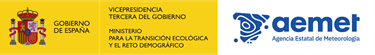

# Librería Pandas

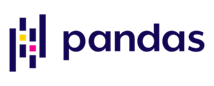

(basado en el tutorial "10 minutes to pandas" https://pandas.pydata.org/pandas-docs/stable/10min.html )

Para abrir el notebook en Colab o Binder pulsa el botón respectivo:

<a target="_blank" href="https://colab.research.google.com/github/pibm-curso/python_para_meteorologia/blob/main/librerias_cientificas/1_pandas.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
    
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/pibm-curso/python_para_meteorologia/HEAD?urlpath=%2Fdoc%2Ftree%2Flibrerias_cientificas%2F1_pandas.ipynb)

Detecta si se ejecuta en Google Colab, e instala lo que hace falta:

In [ ]:
import sys

if 'google.colab' in sys.modules:
    !pip install -q openpyxl

Descarga de ficheros de ejemplo:

In [ ]:
!test -f buenos_aires_20230813_3h.txt || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/buenos_aires_20230813_3h.txt -O buenos_aires_20230813_3h.txt
!test -f buenos_aires_20230813.txt || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/buenos_aires_20230813.txt -O buenos_aires_20230813.txt
!test -f buenos_aires_20230813.xlsx || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/buenos_aires_20230813.xlsx -O buenos_aires_20230813.xlsx
!test -f onamet_20230824.csv  || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/onamet_20230824.csv -O onamet_20230824.csv
!test -f Estacion_ATLACOMULCO_1_semana.csv || wget https://raw.githubusercontent.com/pibm-curso/python_para_meteorologia/refs/heads/main/librerias_cientificas/examples/Estacion_ATLACOMULCO_1_semana.csv -O Estacion_ATLACOMULCO_1_semana.csv

## Introducción

Pandas (http://pandas.pydata.org) es una librería de acceso abierto (open source), con licencia BSD que proporciona estructuras y herramientas de análisis de datos de altas prestaciones y fáciles de usar escritas en lenguaje Python. Es parte del ecosistema Scipy (https://projects.scipy.org).

Numpy es la librería básica de cálculo en python, con la matriz multidimensional np.array como su estructura fundamental.

Sin embargo nosotros estudiaremos directamente Pandas, que es una librería especializada en el análisis de datos que puede sernos más útil, aunque nos referiremos en alguna ocasión a Numpy. Pandas tiene dos características que la hacen especialmente interesante: permite utilizar datos heterogéneos, y utilizar etiquetas para identificar datos tabulados fácilmente.

Observar, en cualquier caso, que ambas librerías tienen muchos métodos comunes, por lo que gran parte de la funcionalidad aprendida en Pandas será aplicable también en Numpy (aunque con una sintaxis diferente).

**Características de Pandas**

Ventajas:
- Más versatilidad que numpy en el manejo de arrays: permite tablas no homogéneas, nombres de las columnas
- Maneja muy bien series temporales
- Gran cantidad de funciones “off-the-shelf”: implementadas, testeadas, y listas para usar
- Código corto y fácil de leer

Desventajas:
- Ocupa más memoria
- Código mucho más difícil de escribir si esa funcionalidad no la hace ya pandas
- Curva de aprendizaje dura
- R dispone de herramientas más potentes de análisis estadístico, aunque Pandas es parte de un lenguaje de propósito general.

## Creación de series y dataframes

Objetos más importantes:
- Series (1 dimensión)
- DataFrame (2 dimensiones)

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

Creación de una serie a partir de una lista:

In [ ]:
s = pd.Series(['angel',3,5,np.nan,6,8])
s

Un dataframe se puede crear de varias formas distintas. En primer lugar se puede crear a partir de un diccionario. Tomamos datos de precipitación de tres estaciones del CENAOS, el Centro de Estudios Atmosféricos, Oceanográficos y Sísmicos de Honduras, como ejemplo:

In [ ]:
df = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)],
                   'PCP 1h':[0.0, 0.0, 0.0], 
                   'PCP 6h':[7.6, 0.1, 0.0],
                   'PCP 12h':[11.7, 0.1, 7.3],
                   'PCP 24h':[11.7, 19.2, 18.8]})


In [ ]:
df

Observar que las columnas pueden tener distintos tipos de datos:

In [ ]:
df.dtypes

También se puede crear un dataframe especificando cada una de sus filas:

In [ ]:
df = pd.DataFrame([['Los Platos', datetime(2023,8,27,12), 0.0, 7.6, 11.7, 11.7], 
                   ['Atima', datetime(2023,8,27,12), 0.0, 0.1, 0.1, 19.2],
                   ['Bomberos-Tegucigalpa', datetime(2023,8,27,12), 0.0, 0.0, 7.3, 18.8]],
                  columns=['Estacion', 'Date', 'PCP 1h', 'PCP 6h', 'PCP 12h', 'PCP 24h'])
df

Otra alternativa es cargar los datos a partir de un fichero csv (lo estudiaremos en detalle más adelante). Por ejemplo, estos datos de Buenos Aires tomados de la web del Servicio Meteorológico Nacional de Argentina:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", sep=",", encoding = "ISO-8859-1")
df

O también a partir de un fichero Excel: 

In [ ]:
df = pd.read_excel("buenos_aires_20230813.xlsx")
df

## Indices

Hay una cierta equivalencia entre DataFrames y tablas de una base de datos.

Los índices pueden ser muy útiles cuando haya que seleccionar datos en un gran dataframe, o si hay que unir dos de ellos.

Para crear un índice usaremos la función ``set_index``:

In [ ]:
df = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)],
                   'PCP 1h':[0.0, 0.0, 0.0], 
                   'PCP 6h':[7.6, 0.1, 0.0],
                   'PCP 12h':[11.7, 0.1, 7.3],
                   'PCP 24h':[11.7, 19.2, 18.8]})
df

In [ ]:
df.set_index('Date', inplace=True)
df

El índice también se puede definir simultáneamente al crear el dataframe:

In [ ]:
df = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'PCP 1h':[0.0, 0.0, 0.0], 
                   'PCP 6h':[7.6, 0.1, 0.0],
                   'PCP 12h':[11.7, 0.1, 7.3],
                   'PCP 24h':[11.7, 19.2, 18.8]},
                  index = [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)])
df

Para eliminar el índice:

In [ ]:
df.reset_index(inplace=True)
df

Observar que muchas funciones, como ``set_index``, devuelven un dataframe como salida:

In [ ]:
df = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)],
                   'PCP 1h':[0.0, 0.0, 0.0], 
                   'PCP 6h':[7.6, 0.1, 0.0],
                   'PCP 12h':[11.7, 0.1, 7.3],
                   'PCP 24h':[11.7, 19.2, 18.8]})

In [ ]:
df.set_index('Date')

pero no modifican el dataframe original:

In [ ]:
df

Para modificar el dataframe original hay que incluir la opción *inplace* o modificar el propio dataframe:

In [ ]:
df.set_index('Date', inplace=True)
# o:
#df = df.set_index('Date', inplace=False) # inplace toma el valor False por defecto

Es posible crear multiíndices, índices de más de un campo:

In [ ]:
df = df.set_index(['Date', 'Estacion'])
df

## Manejo de series temporales

La función ``date_range`` resulta muy útil para crear rangos de fechas:

In [ ]:
pd.date_range("20230801", "20230803")

o en un formato string:

In [ ]:
pd.date_range(start="20230801", end="20230803").format()

Entre otras cosas, se puede modificar la frecuencia:

In [ ]:
pd.date_range("20230801", "20230803", freq="6H").format()

En meteorología, es muy común tener datos ordenados por fechas. Pandas se adapta muy bien a esta necesidad, y nos permite utilizar la fecha como índice de nuestros DataFrames. De hecho dispone de un objeto específico para ello, el DataTimeIndex:

In [ ]:
df = pd.DataFrame({'Tmax':[20.3, 21.5, 20.1, 22.0]},
                  index = pd.date_range("20230801", "20230804"))
df

El índice es un objeto DataTimeIndex:

In [ ]:
df.index

que tiene sus métodos específicos, por ejemplo:

In [ ]:
print(df.index.month)
print(df.index.day)

In [ ]:
print(df.index)

## Visualización de las características de un DataFrame

Para manejar adecuadamente un dataframe debemos conocer sus características: qué columnas tiene, qué tipo de datos almacena, etc.
Hay varias propiedades y métodos que nos dan esa información.

Creemos un dataframe a partir del fichero csv de Buenos Aires, tomando como índice la fecha y la hora (más adelante veremos cómo se combinan estos dos campos en uno):

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", parse_dates=[['Fecha', 'Hora']], 
                 sep=",", encoding = "ISO-8859-1")
df = df.set_index('Fecha_Hora')

In [ ]:
df

Como ya hemos visto, para mostrar el índice del dataframe escribiremos:

In [ ]:
df.index

*columns* devuelve una lista con el nombre de cada columna (por cierto, es un objeto índice). Observar que el índice ya no se considera una columna:

In [ ]:
print(df.columns)
print(df.columns[3])

*dtypes* da información sobre el tipo de dato de cada columna:

In [ ]:
df.dtypes

*values* devuelve el dataframe en forma de array de numpy

In [ ]:
print(df.values)
print(type(df.values))

``describe`` es un método que da un resumen de varios estadísticos para el dataframe:

In [ ]:
df.describe()

Cada uno de estos estadísticos es un método del dataframe:

In [ ]:
df.count()

Hay más estadísticos disponibles:

In [ ]:
df.quantile(0.5)

In [ ]:
df.quantile(0.666, axis=1)

Hay otras operaciones sencillas que nos pueden resultar útiles. La traspuesta (``T``):

In [ ]:
df.T

Y ordenar, ya sea por índice o por columna (``sort_index`` y ``sort_values`` respectivamente). Recordar que sort_index no cambia el dataframe, a no ser que añadamos la opción inplace=True

In [ ]:
df.sort_index()

In [ ]:
df.sort_values(by="T (°C)")

Notar que podemos ordenar por filas, pero también por columnas:

In [ ]:
df.sort_index(axis=1)

``rename`` permite cambiar de nombre a las columnas elegidas. Tampoco se modifica el dataframe, a no ser que se utilice la opción inplace=True:

In [ ]:
df.rename(columns={'T (°C)': 'Temperatura', 'HR (%)': 'Humedad relativa'})

## Seleccionar y modificar valores

Partimos de nuestro dataframe habitual:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", parse_dates=[['Fecha', 'Hora']], 
                 sep=",", encoding = "ISO-8859-1")
df = df.set_index('Fecha_Hora')

Para seleccionar una columna de un dataframe podemos utilizar el operador []. Esto nos devolverá una serie (reducimos su dimensión):

In [ ]:
s = df['Estado']   # También podría ponerse s = df.Estado
s

Para obtener un dataframe tendríamos que usar [[]]:

In [ ]:
df[['T (°C)', 'HR (%)']]

De la misma forma, aplicando este operador al índice de una serie, nos devuelve un valor:

In [ ]:
s['2023-08-13 12:00:00']

También podemos seleccionar varias filas:

In [ ]:
df['2023-08-13 12:00:00':'2023-08-13 14:00:00']

o usando la posición, como se hace en python estándar 

In [ ]:
df[10:13]

De todas formas, en un programa es mejor utilizar los métodos *loc* e *iloc* que están más optimizados. Además estos métodos nos evitan problemas relacionados con vistas y copias.

*loc* permite seleccionar subconjuntos de nuestra estructura (serie o dataframe), según etiquetas. Para seleccionar columnas:

In [ ]:
df[['T (°C)', 'Estado']]

In [ ]:
df.loc[:, ('T (°C)', 'Estado')]

y para seleccionar filas:

In [ ]:
df.loc['2023-08-13 12:00:00', :]

o ambos a la vez:

In [ ]:
df.loc['2023-08-13 12:00:00':'2023-08-13 14:00:00', 
       ('T (°C)', 'Estado')]

<div style="background-color: #e2f0fd; padding: 12px; border: 1px solid #b8daff; border-radius: 6px; color: #004085;">
    <b>Nota:</b> observar que en la selección por etiquetas, tanto el elemento inicial como el final se incluyen (al contrario de lo que ocurre en una lista)
</div>

*iloc* selecciona subconjuntos según su posición. De forma equivalente a los ejemplos anteriores:

In [ ]:
df.iloc[2]

o también:

In [ ]:
df.iloc[2, :]

In [ ]:
df = df.reset_index()
df

In [ ]:
df.loc[2:4, ('T (°C)', 'Estado')]

In [ ]:
df.iloc[2:5, 1:3]

También se pueden hacer selecciones discontinuas, como haríamos en python estándar:

In [ ]:
df.iloc[[1,2,4], [2,5]]

E incluso un elemento:

In [ ]:
df.iloc[0,0]

Aunque para seleccionar elementos es mejor utilizar el método *at* (o el *iat*), que son más rápidos y eficientes:

In [ ]:
df = df.set_index('Fecha_Hora')

In [ ]:
df.at['2023-08-13 23:00:00', 'HR (%)']

In [ ]:
df.iat[1,4]

Otra forma de realizar selecciones es mediante la **indexación booleana**, que nos permite seleccionar valores de acuerdo a una condición relativa al dataframe.

Por ejemplo, si queremos seleccionar las filas para las que la GHI es mayor de 500, tenemos que usar esta condición:

In [ ]:
df.index.hour==15

y si introducimos esta serie de booleanos en nuestro dataframe, imponemos la condición:

In [ ]:
df[df.index.hour==15]

Se pueden utilizar operadores booleanos (&, |, ~) para construir condiciones más complicadas:

In [ ]:
df[(df['T (°C)']>14.0) & (df['HR (%)']>30.0)] 

No solo se pueden realizar selecciones sobre filas o columnas, también sobre valores. En este caso se da el valor np.nan a los elementos donde no se cumpla la condición:

In [ ]:
df_num = df[['T (°C)', 'HR (%)']]

In [ ]:
(df_num>15) & (df_num<40)

In [ ]:
df_num[(df_num>15) & (df_num<40)]

Se pueden dar valores a filas, columnas o elementos determinados aplicando la sintaxis y métodos anteriores:

In [ ]:
df.loc['2023-08-13 09:00:00.0':'2023-08-13 11:00:00.0', 
       ('T (°C)', 'HR (%)')] = 5.0
df

También se pueden crear nuevas columnas:

In [ ]:
df['T*2']=df['T (°C)']**2
df

Para aplicar una función a toda una columna usaremos la función *apply*:

In [ ]:
from numpy import sqrt

In [ ]:
df['T (°C)'].apply(np.sqrt)

Hay una gran cantidad de funciones para modificar columnas.
Por ejemplo, si queremos formatear la velocidad del viento, y convertirla en un valor numérico para poder operar con ella, podemos hacer lo siguiente:

In [ ]:
df['Viento velocidad'].str.slice(stop=-5).apply(float)

## Entrada / salida

Aunque es posible definir un dataframe directamente, como hemos hecho en apartados anteriores, es más habitual leer los datos de uno varios ficheros. Para leer ficheros csv (el caso más habitual) utilizaremos la función *read_csv*.

Esta función tiene una gran cantidad de argumentos opcionales posibles, aunque en su versión más simple, solo necesita un argumento, el nombre de fichero. Otros argumentos que usaremos a menudo son: *sep*, *header*, *skiprows*, *index_col*, *names*, *parse_dates* y *usecols*.

Por ejemplo, si queremos leer la columna de la temperatura (T (°C)) del fichero *buenos_aires_20230813.txt*:

In [ ]:
!head buenos_aires_20230813.txt

escribiríamos, por ejemplo:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt",
                 sep=",", encoding = "ISO-8859-1", index_col=0, header=0, usecols=[0,3])
df

- *encoding="ISO-8859-1"* indica que no estamos utilizando las letras del inglés, sino las del español, (así podemos usar tildes).  
- *header=0* indica que la primera línea es la cabecera.  
- *usecols=[0,3]* indica que tomamos la primera (la fecha) y la cuarta columna (la temperatura).  

Notar que solo ha tomado la primera columna, la fecha, como índice

Observar que read_csv nos permite hacer conversiones automáticamente, por ejemplo nos permite crear el índice a la vez que leemos el fichero. Pero podemos hacer esto mismo en dos pasos:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt",
                 sep=",", encoding = "ISO-8859-1", header=0, usecols=[0,3])
df = df.set_index('Fecha')

Aunque read_csv trata de convertir al tipo adecuado cada columna (por ejemplo para *floats*), no hace esta conversión para objetos tipo datetime. Para ello podemos usar el argumento *parse_dates*, que además nos permite combinar el campo de la fecha y de la hora y así obtener un campo datetime bien formado:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", parse_dates=[[0,1]], sep=",",
                 index_col=0, encoding = "ISO-8859-1")
# También podríamos haber tomado parse_dates=[['Fecha', 'Hora']]
df

Otra alternativa es hacer esta conversión separadamente, utilizando la función *to_datetime*:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", sep=",", encoding = "ISO-8859-1")
df["Fecha_Hora"] = pd.to_datetime(df["Fecha"] + " " + df["Hora"], format="%d/%m/%Y %H:%M")
df

Ahora ya tiene el formato datetime:

In [ ]:
print(df.dtypes)

También disponemos del argumento *converters* para forzar cambios de tipo que *read_csv* no haga apropiadamente.

O, un poco más corto:

<div style="background-color: #e2f0fd; padding: 12px; border: 1px solid #b8daff; border-radius: 6px; color: #004085;">
    <b>Nota:</b> En general *read_csv* espera que el fichero csv tenga siempre el número de columnas correcto. De todas formas, el argumento *on_bad_lines* y *warn_bad_lines* puede ayudarnos a controlar ficheros mal formateados, hasta cierto punto.
</div>

También existe la función *read_fwf*, que permite leer ficheros donde no hay separadores, sino que cada columna tiene una longitud fija.

Para volcar un dataframe a un fichero utilizaremos el método *to_csv*. Tiene argumentos parecidos.

Además de ficheros csv, Pandas es capaz de leer directamente muchos otros formatos, como HDF (*read_hdf*), json (*read_json*) o SQL (*read_sql*), o tablas de html (*read_html*).

En particular, es capaz de leer ficheros Excel también (utiliza el módulo xlrd, que no es parte de la librería estándar).

## Datos nulos

Pandas utiliza el valor *np.nan* para representar datos nulos o no conocidos. Por ejemplo en nuestro dataframe con datos de Buenos Aires, no hay dato de velocidad del viento entre las 3 y las 6 de la madrugada:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", parse_dates=[[0,1]], sep=",",
                 index_col=0, encoding = "ISO-8859-1")
df

Por defecto estos valores no son incluidos en las operaciones, aunque es conveniente examinar cada función para estar seguro. Por ejemplo:

In [ ]:
len(df)

pero por otra parte:

In [ ]:
df.count()

Algunas funciones, como ``mean``, tienen un argumento (*skipna* en este caso), para decidir si se incluyen o no los NaN (por defecto skipna=True, y no los incluirá).

Por ejemplo, si convertimos la velocidad del viento a un valor numérico, y calculamos su media, vemos que:

In [ ]:
df['Vel.Viento']=df['Viento velocidad'].str.slice(stop=-5).apply(float)

In [ ]:
df['Vel.Viento'].mean()

In [ ]:
df['Vel.Viento'][0:18].mean()

In [ ]:
df['Vel.Viento'].mean(skipna=False)

Las funciones ``isnull`` y ``notnull`` nos dirán si un valor es igual a NaN. ¡No hagáis comparaciones del tipo x==np.nan!

In [ ]:
pd.isnull(df)

Se pueden eliminar las filas con valores NaN con el método ``dropna``:

In [ ]:
df.dropna()  # Notar que para que se guarden los cambios debemos incluir inplace=True

<div style="background-color: #e2f0fd; padding: 12px; border: 1px solid #b8daff; border-radius: 6px; color: #004085;">
    <b>Nota:</b> Para comprobar si un dataframe está vacío utilizaremos el atributo ``empty``
</div>

Para rellenar con otros valores utilizaremos el método ``fillna``. Podemos rellenar con un valor concreto, 

In [ ]:
df.fillna(-999.0)

o utilizar un método; por ejemplo rellenando con el próximo valor no nulo:

In [ ]:
df.fillna(method='bfill')

También se puede interpolar entre los valores no nulos más cercanos, utilizando el método ``interpolate``.

<div style="background-color: #d4edda; padding: 15px; border-radius: 5px; border-color: #c3e6cb;">
    <b>Ejercicio:</b> El reindexado es un método que suele producir muchos valores nulos, que después habrá que rellenar de forma adecuada. Puedes practicar los métodos anteriores en el dataframe *dfmissing*, que obtenemos con este código que previamente ha leído datos de Buenos Aires cada 3 horas, y ha rellenado las horas faltantes con nulos:
</div>

In [ ]:
df = pd.read_csv("buenos_aires_20230813_3h.txt", parse_dates=[[0,1]], sep=",",
                 index_col=0, encoding = "ISO-8859-1")[['T (°C)', 'HR (%)']].sort_index()

dfmissing = df.reindex(index=pd.date_range("20230813 03:00", "20230814 00:00", freq="H"))
dfmissing

## Merge, concat, append

Pandas permite combinar varios dataframes (o series), de dos formas básicas: 
- Concatenar dos (o más) dataframes con las mismas columnas simplemente "pegándolos", para lo que usaremos la función *concat*. Otra función relacionada es *append*.
- Unir dos dataframes por medio de un campo común, de forma que el nuevo dataframe tendrá las columnas de ambos. Esta operación se realiza por medio de la función *merge*.

Si tenemos estos dataframes, con datos del CENAOS:

In [ ]:
# Observaciones en dos horas distintas:
dfobs1 = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)],
                   'PCP 1h':[0.0, 0.0, 0.0], 
                   'PCP 6h':[7.6, 0.1, 0.0],
                   'PCP 12h':[11.7, 0.1, 7.3],
                   'PCP 24h':[11.7, 19.2, 18.8]})

dfobs2 = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,28,2), datetime(2023,8,28,2), datetime(2023,8,28,2)],
                   'PCP 1h':[1.5, 0.0, 0.0], 
                   'PCP 6h':[1.5, 0.4, 0.0],
                   'PCP 12h':[1.5, 8.3, 64.0],
                   'PCP 24h':[13.2, 8.4, 71.3]})

In [ ]:
# Predicciones (hipotéticas) en una hora determinada:
dfpred = pd.DataFrame({'Estacion':['Los Platos', 'Atima', 'Bomberos-Tegucigalpa'], 
                   'Date': [datetime(2023,8,27,12), datetime(2023,8,27,12), datetime(2023,8,27,12)],
                   'PCPpred 1h':[0.0, 0.0, 0.0], 
                   'PCPpred 6h':[5.0, 0.0, 0.0],
                   'PCPpred 12h':[10.0, 0.0, 5.0],
                   'PCPpred 24h':[15.0, 19.2, 25.0]})

Los podemos concatenar de esta forma:

In [ ]:
dfobs = pd.concat([dfobs1, dfobs2])
dfobs

También se pueden concatenar según el otro eje (en este caso no tiene mucho sentido):

In [ ]:
pd.concat([dfobs1, dfobs2], axis=1)

La segunda forma consiste en unir los dos dataframes por medio de un campo común, de forma similar a como se hace en el lenguaje SQL, utilizado habitualmente en bases de datos relacionales. Indicaremos los dos dataframes a unir, y el campo (o campos) respectivo que usaremos como nexo de unión:

In [ ]:
df = pd.merge(dfobs, dfpred, left_on=['Estacion', 'Date'], right_on=['Estacion', 'Date'])
df

o, más sencillo en este caso:

In [ ]:
df = pd.merge(dfobs, dfpred, on=['Estacion', 'Date'])
df

Ahora podríamos calcular por ejemplo el error de la predicción fácilmente:

In [ ]:
df["PCPerror 24h"] = abs(df["PCPpred 24h"] - df["PCP 24h"])
df

También se pueden usar índices para realizar la unión. Este es un método más rápido si los dataframes son grandes (notar que esto ocurre también en bases de datos):

In [ ]:
dfobs = dfobs.set_index(['Estacion', 'Date'])
dfpred = dfpred.set_index(['Estacion', 'Date'])

In [ ]:
df = pd.merge(dfobs, dfpred, left_index=True, right_index=True)
df

Observar que las uniones cuando se usan índices únicos serán uno-a-uno, pero al utilizar columnas pueden ser muchos-a-muchos. Si no escogemos bien la unión, podemos obtener el producto cartesiano por error: 

In [ ]:
pd.merge(dfobs, dfpred, on='Estacion')

En los ejemplos anteriores vemos que al realizar el cruce, tomamos la intersección de los registros, o sea, cogemos solo aquellos donde coincide la columna unión. El argumento *how* nos permite escoger la intersección (con el valor *"inner"*, que es el usado por defecto), la unión (valor *"outer"*), o tomar uno de los dataframes como dominante (para los valores *"left"* y *"right"*). Para estos casos se pone el valor nulo en aquellos registros que no existían.

In [ ]:
pd.merge(dfobs, dfpred, left_index=True, right_index=True, how='inner')

In [ ]:
pd.merge(dfobs, dfpred, left_index=True, right_index=True, how='outer')

In [ ]:
pd.merge(dfobs, dfpred, left_index=True, right_index=True, how='left')

In [ ]:
pd.merge(dfobs, dfpred, left_index=True, right_index=True, how='right')

## Agrupar

Agrupar datos es un proceso con tres partes diferenciadas:  

- División de los datos en grupos según un cierto criterio  
- Aplicación de una función a cada uno de los grupos de forma independiente
- Combinación de los grupos para formar una nueva estructura de datos  

Esta operación proviene también del lenguaje SQL, donde se utiliza la expresión "group by" para hacer lo mismo.

Partimos de nuestro dataframe de ejemplo con 6 observaciones (2 observaciones para 3 estaciones):

In [ ]:
dfobs

Para realizar el primer paso, la división en grupos, usaremos el método ``groupby``. Se pueden utilizar muchos criterios o claves (*keys*) para dividir.

La clave más habitual es una columna (o varias) del dataframe:

In [ ]:
grouped_st = dfobs.groupby('Estacion')

<div style="background-color: #e2f0fd; padding: 12px; border: 1px solid #b8daff; border-radius: 6px; color: #004085;">
    <b>Nota:</b> En realidad esto es "azúcar sintáctico", creado para facilitarnos la escritura de código. Los grupos no se crean hasta que no son utilizados.
</div>

Es posible iterar el objeto *groupby* para ver qué contiene cada grupo:

In [ ]:
for name, group in grouped_st:
    print("*** Grupo %s ***"%str(name))
    print(group)

También podemos dividir según el índice:

In [ ]:
grouped_dt = dfobs.groupby(dfobs.index)

In [ ]:
for name, group in grouped_dt:
    print("*** Grupo %s ***"%str(name))
    print(group)

O incluso aplicando una función:

In [ ]:
def PCP_higher_than_10(df):
    return df['PCP 12h']>10

grouped_pcp10 = dfobs.groupby(PCP_higher_than_10(dfobs))

In [ ]:
for name, group in grouped_pcp10:
    print("*** Grupo %s ***"%str(name))
    print(group)

Además de las filas, también se pueden dividir las columnas, utilizando el argumento *axis*. Se puede encontrar una lista detallada de las claves posibles en https://pandas.pydata.org/pandas-docs/stable/groupby.html

El atributo *groups* es un diccionario cuyas claves son los nombres de los grupos, y los valores las etiquetas del eje correspondiente a cada grupo:

In [ ]:
grouped_st.groups

Se selecciona un grupo determinado con el método ``get_group``:

In [ ]:
grouped_st.get_group('Atima')

Después de agrupar, podemos aplicar una función a cada grupo, aplicándola directamente al objeto *groupby*:

In [ ]:
grouped_st.sum()

Podemos elegir una columna únicamente:

In [ ]:
grouped_st['PCP 24h'].mean()

Y también aplicar diferentes funciones a distintas columnas, por medio del método ``agg`` (o ``aggregate``):

In [ ]:
grouped_st.agg({'PCP 12h': np.mean, 'PCP 24h': np.std})

o si renombramos para que quede más bonito: 

In [ ]:
grouped_st.agg({'PCP 12h': np.mean, 'PCP 24h': np.std}).rename(
                 columns={'PCP 12h':'mean_PCP 12h', 'PCP 24h': 'std_PCP 24h'})

<div style="background-color: #d4edda; padding: 15px; border-radius: 5px; border-color: #c3e6cb;">
    <b>Ejercicio:</b> Para este ejercicio utilizaremos datos de un fichero csv de la estación de Atlacomulco, extraído de la web del Servicio Meteorológico Nacional de México. Realice las siguientes operaciones:

1. Cargue el fichero en un dataframe de Pandas, convirtiendo las fechas a Timestamps, y tomando la fecha local como índice (pista: tendrá que saltarse las primeras líneas de metadatos con la opción *skiprows*).
2. Seleccione los registros con una temperatura mayor de 20 °C y humedad relativa menor de 40%
3. Seleccione los registros que corresponden a las 12 horas hora local únicamente (para cada día).
4. Calcule la media y desviación estandar de la radiación solar
5. Cree dos dataframes nuevos, el primero incluyendo solo los datos correspondientes al día 25 de agosto y el segundo los datos del día 27 de agosto.
6. Una los dos dataframes en uno (con *concat*)
7. Divida el dataframe en tres más pequeños, de forma que cada uno contenga información únicamente sobre la temperatura, humedad relativa y radiación solar, respectivamente.
8. Vuelva a unir los tres dataframes en uno (con *merge*).
9. Calcule la temperatura máxima y mínima para cada día, del 24 al 28 de agosto (pista: tendrá que agrupar con groupby).
</div>

In [ ]:
import pandas as pd

# 1.
df = pd.read_csv("Estacion_ATLACOMULCO_1_semana.csv", parse_dates=[0], skiprows=9,
                  sep=",", encoding = "ISO-8859-1", index_col=[0])
# 2.
df[(df["Temperatura del Aire (°C)"]> 20.0) & (df["Humedad relativa (%)"] < 40.0)]
# 3.
df[(df.index.hour==12) & (df.index.minute==0)]
# 4.
df["Radiación Solar (W/m2)"].mean()
df["Radiación Solar (W/m2)"].std()
# 5.
df25ago = df.loc[df.index.day==25, :]
df27ago = df.loc[df.index.day==27, :]
# 6.
df_con = pd.concat([df25ago, df27ago])
# 7.
df_t = df[["Temperatura del Aire (°C)"]]
df_hr = df[["Humedad relativa (%)"]]
df_rs = df[["Radiación Solar (W/m2)"]]
# 8. 
df_mer = pd.merge(df_t, df_hr, left_index=True, right_index=True)
df_mer = pd.merge(df_mer, df_rs, left_index=True, right_index=True)
# 9.
gr_day = df.groupby(df.index.day)
gr_day["Temperatura del Aire (°C)"].max()
gr_day["Temperatura del Aire (°C)"].min()

## Reshaping: stack, pivot

Partimos de este dataframe (con su índice):

In [ ]:
dfobs

El método ``stack`` "comprime" una de las columnas de un dataframe. El método inverso es ``unstack``.

In [ ]:
dfobs.stack()

Para "pivotar" un dataframe usaremos la función ``pivot_table``:

In [ ]:
dfobs = dfobs.reset_index()

In [ ]:
df_pivot = pd.pivot_table(dfobs, values='PCP 12h', index='Date', columns='Estacion')
df_pivot

Se puede pivotar más de una columna:

In [ ]:
pd.pivot_table(dfobs, values=['PCP 1h', 'PCP 6h', 'PCP 12h', 'PCP 24h'], 
               index='Date', columns='Estacion')

La función ``melt`` es la función inversa de ``pivot_table``:

In [ ]:
pd.melt(df_pivot.reset_index(), id_vars = 'Date', value_name = 'PCP 24h')

## Gráficos

El objeto dataframe dispone de un método ``plot`` para realizar gráficos. Este método es simplemente un wrapper de la función ``plot`` de ``matplolib.pyplot``, y se usa de forma similar:

In [ ]:
df = pd.read_csv("buenos_aires_20230813.txt", parse_dates=[['Fecha', 'Hora']], 
                 sep=",", encoding = "ISO-8859-1")

In [ ]:
df["T (°C)"].plot()